In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Change this to your actual dataset folder path in Drive
dataset_path = '/content/drive/MyDrive/Railway_Fault_Dataset'


Mounted at /content/drive


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Set parameters
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 25

# Define custom CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # For binary classification
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 1131 images belonging to 2 classes.
Found 282 images belonging to 2 classes.


In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 252s 7s/step - accuracy: 0.7215 - loss: 2.9776 - val_accuracy: 0.5638 - val_loss: 1.8709
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9254 - loss: 0.1630 - val_accuracy: 0.7589 - val_loss: 8.8480
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.9638 - loss: 0.0993 - val_accuracy: 0.7589 - val_loss: 19.5810
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.9806 - loss: 0.0447 - val_accuracy: 0.7589 - val_loss: 26.0068
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.9824 - loss: 0.0650 - val_accuracy: 0.7589 - val_loss: 29.2388
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.9876 - loss: 0.0358 - val_accuracy: 0.7589 - val_loss: 32.1956
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.9908 - loss: 0.0239 - val_accuracy: 0.7589 - val_loss: 32.3810
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.9882 - loss: 0.0461 - val_accuracy: 0.758

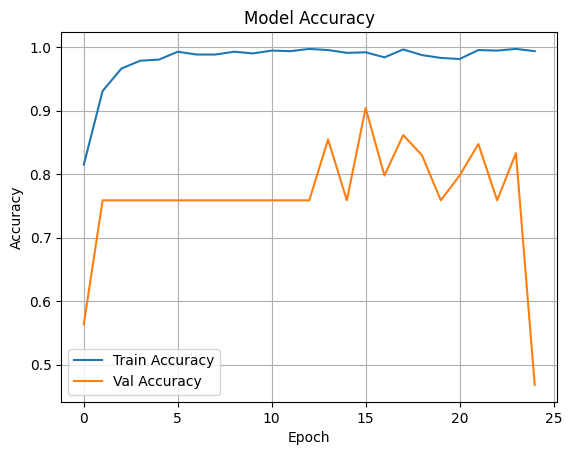

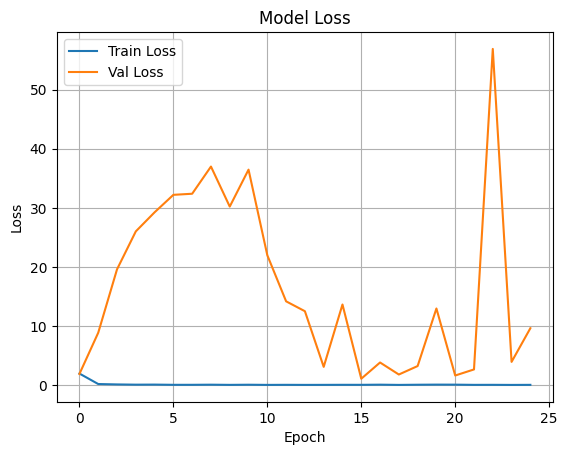

In [11]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_generator)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.4266 - loss: 9.0705
Validation Accuracy: 45.39%


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
val_generator.reset()
preds = model.predict(val_generator)
predicted_classes = (preds > 0.5).astype("int32").reshape(-1)

# True labels
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))


9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step
Classification Report:
              precision    recall  f1-score   support

      Defect       0.87      0.27      0.41       214
  Non-Defect       0.27      0.87      0.42        68

    accuracy                           0.41       282
   macro avg       0.57      0.57      0.41       282
weighted avg       0.72      0.41      0.41       282

Confusion Matrix:
[[ 58 156]
 [  9  59]]


In [15]:
# Accuracy from training history
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy (from history): {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy (from history): {val_acc * 100:.2f}%")

# Accuracy from model evaluation
train_loss, train_eval_acc = model.evaluate(train_generator)
val_loss, val_eval_acc = model.evaluate(val_generator)

print(f"Evaluated Training Accuracy: {train_eval_acc * 100:.2f}%")
print(f"Evaluated Validation Accuracy: {val_eval_acc * 100:.2f}%")


Final Training Accuracy (from history): 99.38%
Final Validation Accuracy (from history): 46.81%
36/36 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5545 - loss: 5.5247
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.4527 - loss: 10.0836
Evaluated Training Accuracy: 52.79%
Evaluated Validation Accuracy: 45.74%
